In [51]:
import os
path_project = os.path.dirname(os.path.abspath('.'))
import sys
sys.path.append(os.path.join(path_project, 'src'))
sys.path.append(os.path.join(path_project, 'exp/script'))
import results_saver
import options
import copy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import utility_experiment
import matplotlib

img_path = os.path.join(path_project, 'exp', 'img')
results_path = os.path.join(path_project, 'exp', 'results')
default_args = options.build_default_args(path_project)

PLOT_MARKERS = ['o', 'v', 's', 'X', 'p', '*', 'h', '^', '<', '>', 'H', 'D', 'd', 'P']
METHOD_ORDER = ["DEFAULT", "ULDP-NAIVE", "ULDP-GROUP-2", "ULDP-GROUP-4", "ULDP-GROUP-8", "ULDP-SGD", "ULDP-AVG"]

## Hyper parameters


In [60]:
# ハイパラ関係

def hp_exp_results(dataset_name, method, n_users, dist):
    exp_args = copy.deepcopy(default_args)
    exp_args.dataset_name = dataset_name
    exp_args.agg_strategy = method
    exp_args.n_users = n_users
    exp_args.hyper_parameter_tuning = 1
    args = utility_experiment.build_exp_paramerters(exp_args, dataset_name, dist, method, n_users)
    result_list, hash_args = results_saver.load_results(args, path_project, hp=True)
    return result_list[0]["exp"], hash_args


def best_hp_info(dataset_name, method, n_users, dist):
    hp_result, _ = hp_exp_results(dataset_name, method, n_users, dist)
    best_params = hp_result["hp_results"]["best_params"]
    best_value = hp_result["hp_results"]["best_value"]
    return best_params, best_value


def plot_hps(dataset_name, method, n_users, dist):
    hp_result, hash_args = hp_exp_results(dataset_name, method, n_users, dist)
    print("hash_args", hash_args)
    result_details = hp_result["hp_results"]["result_details"]
    x_learning_rate = []
    y_clippling_bound = []
    w_error_rate = []

    for i in range(len(result_details)):
        x_learning_rate.append(result_details[i]["params"]["learning_rate"])
        y_clippling_bound.append(result_details[i]["params"]["clipping_bound"])
        w_error_rate.append(result_details[i]["error_rate"])

    x_learning_rate = np.array(x_learning_rate)
    y_clippling_bound = np.array(y_clippling_bound)
    w_error_rate = np.array(w_error_rate)

    if method != "ULDP-SGD":
        z_epochs = []
        for i in range(len(result_details)):
            z_epochs.append(result_details[i]["params"]["epochs"])
        z_epochs = np.array(z_epochs)

    # Color map c=
    w_error_rate = np.array(w_error_rate)
    norm = plt.Normalize(w_error_rate.min(), w_error_rate.max())
    colors = plt.cm.jet(norm(w_error_rate))
    # Size map s=
    sizes = w_error_rate * 5000

    if method == "ULDP-SGD":
        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(
            x=x_learning_rate,
            y=y_clippling_bound,
            hue=w_error_rate,
            palette='viridis',
            ax=ax,
        )
        ax.set_title("Hyper Parameter scatter plot")
        ax.set_xlabel('learning_rate')
        ax.set_ylabel('clippling_bound')
        fig.savefig(
            os.path.join(results_path, hash_args, "hp.png"),
            dpi=100,
            bbox_inches="tight",
        )

    if method != "ULDP-SGD":
        fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'3d'})
        ax.set_title("Hyper Parameter scatter plot")
        ax.xaxis._set_scale('log')
        ax.yaxis._set_scale('log')
        ax.set_xlabel('learning_rate')
        ax.set_xticks([1e-4, 1e1, 1e2])
        ax.set_ylabel('clippling_bound')
        ax.set_xticks([1e-4, 1e1, 1e2])
        ax.set_zlabel('epochs', labelpad=-4)
        ax.set_zticks([0, 10, 25, 30])
        ax.set(xlim=(1e-4, 100), ylim=(1e-4, 100))
        sc = ax.scatter(x_learning_rate, y_clippling_bound, z_epochs, c=colors)
        fig.colorbar(sc, ax=ax, label='error_rate')
        plt.show()
        fig.savefig(
            os.path.join(results_path, hash_args, "hp.png"),
            dpi=100,
            bbox_inches="tight",
        )

        fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'3d'})
        ax.set_title("Hyper Parameter scatter plot (zoom [1e-3, 1e0])")
        ax.xaxis._set_scale('log')
        ax.yaxis._set_scale('log')
        ax.set_xlabel('learning_rate')
        ax.set_xticks([1e-3, 1e0])
        ax.set_ylabel('clippling_bound')
        ax.set_xticks([1e-3, 1e0])
        ax.set_zlabel('epochs', labelpad=-4)
        ax.set_zticks([0, 10, 25, 30])
        ax.set(xlim=(1e-3, 1e0), ylim=(1e-3, 1e0))
        sc = ax.scatter(x_learning_rate, y_clippling_bound, z_epochs, c=colors)
        fig.colorbar(sc, ax=ax, label='error_rate')
        plt.show()
        fig.savefig(
            os.path.join(results_path, hash_args, "hp-zoom1.png"),
            dpi=100,
            bbox_inches="tight",
        )

        fig, ax = plt.subplots(1, 1, subplot_kw={'projection':'3d'})
        ax.set_title("Hyper Parameter scatter plot (zoom [1e-3, 1e-2])")
        ax.xaxis._set_scale('log')
        ax.yaxis._set_scale('log')
        ax.set_xlabel('learning_rate')
        ax.set_xticks([1e-3, 1e-2])
        ax.set_ylabel('clippling_bound')
        ax.set_xticks([1e-3, 1e-2])
        ax.set_zlabel('epochs', labelpad=-4)
        ax.set_zticks([0, 10, 25, 30])
        ax.set(xlim=(1e-3, 1e-2), ylim=(1e-3, 1e-2))
        sc = ax.scatter(x_learning_rate, y_clippling_bound, z_epochs, c=colors)
        fig.colorbar(sc, ax=ax, label='error_rate')
        plt.show()
        fig.savefig(
            os.path.join(results_path, hash_args, "hp-zoom2.png"),
            dpi=100,
            bbox_inches="tight",
        )


hash_args 35dfc1e1eb


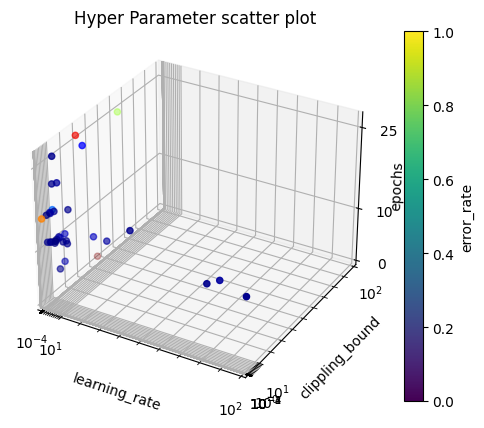

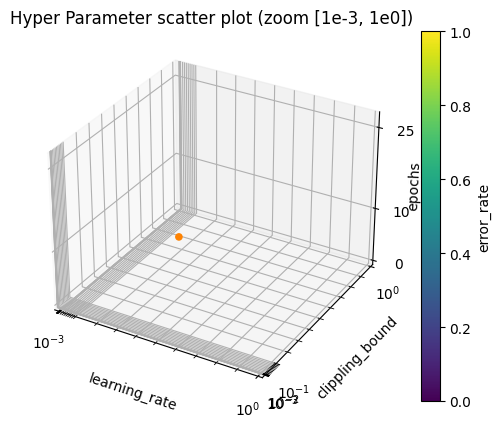

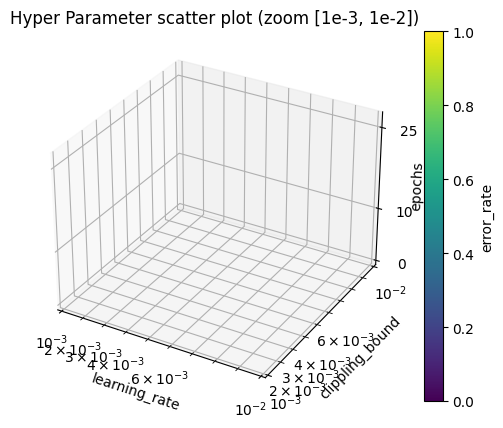

In [64]:
dataset_name = "heart_disease"
method = "ULDP-AVG"
n_users = 1100
dist = None
plot_hps(dataset_name, method, n_users, dist)

## Privacy-Utility tradeoffs

In [54]:
def exp_results(dataset_name, method, n_users, group_k=None, dist=None):
    exp_args = copy.deepcopy(default_args)
    exp_args.dataset_name = dataset_name
    exp_args.agg_strategy = method
    exp_args.n_users = n_users
    if group_k:
        exp_args.group_k = group_k

    args = utility_experiment.build_exp_paramerters(exp_args, dataset_name, dist, method, n_users)
    result_list, hash_args = results_saver.load_results(args, path_project)
    return result_list[0]["exp"], hash_args


def plot_privacy_utility(dataset_name, method, n_users, group_k, dist):
    exp_result_list, hash_args = exp_results(dataset_name, method, n_users, group_k=group_k, dist=dist)
    print("hash_args", hash_args)

    global_test_list = []
    for exp_result in exp_result_list:
        global_test_list.extend(exp_result["global_test"])
        
    global_rounds = [round_idx for round_idx, test_acc, test_loss in global_test_list]
    global_test_acc_list = [
        test_acc for round_idx, test_acc, test_loss in global_test_list
    ]
    global_test_loss_list = [
        test_loss for round_idx, test_acc, test_loss in global_test_list
    ]
    fig, ax = plt.subplots(1, 1)
    sns.lineplot(x=global_rounds, y=global_test_acc_list, marker="o", ax=ax)
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test accuracy", fontsize=18)
    ax.set_title("Test accuracy over rounds", fontsize=20)
    fig.savefig(
        os.path.join(results_path, hash_args, "global_test_acc.png"),
        dpi=100,
        bbox_inches="tight",
    )

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(x=global_rounds, y=global_test_loss_list, marker="o", ax=ax)
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test loss", fontsize=18)
    ax.set_title("Test loss over rounds", fontsize=20)
    fig.savefig(
        os.path.join(results_path, hash_args, "global_test_loss.png"),
        dpi=100,
        bbox_inches="tight",
    )

    if exp_result_list[0].get('privacy_budget'):
        privacy_budget_list = exp_result_list[0]['privacy_budget']
        delta = privacy_budget_list[0][2]
        rounds = [round_idx for round_idx, eps, delta in privacy_budget_list]
        eps_list = [eps for round_idx, eps, delta in privacy_budget_list]
        fig, ax = plt.subplots(1, 1)
        sns.lineplot(x=rounds, y=eps_list, marker="o", ax=ax)
        ax.set_xlabel("round", fontsize=18)
        ax.set_ylabel("epsilon", fontsize=18)
        ax.set_title(f"Epsilon over rounds (delta={delta})", fontsize=20)
        fig.savefig(
            os.path.join(results_path, hash_args, "global_epsilon.png"),
            dpi=100,
            bbox_inches="tight",
        )

    if exp_result_list[0].get('local_model_test'):
        n_total_round = len(exp_result_list[0]["global_test"])
        local_model_test_list = []
        for exp_result in exp_result_list:
            local_model_test_list.extend(exp_result["local_model_test"])
        local_acc_results = {"round_idx": [], "local_metric": [], "silo_id": []}
        local_loss_results = {"round_idx": [], "local_loss": [], "silo_id": []}

        for round_idx, silo_id, local_metric, local_loss in local_model_test_list:
            local_acc_results["round_idx"].append(round_idx)
            local_acc_results["local_metric"].append(local_metric)
            local_acc_results["silo_id"].append(silo_id)

            local_loss_results["round_idx"].append(round_idx)
            local_loss_results["local_loss"].append(local_loss)
            local_loss_results["silo_id"].append(silo_id)

        for round_idx, local_metric, global_loss in zip(global_rounds, global_test_acc_list, global_test_loss_list):
            local_acc_results["round_idx"].append(round_idx)
            local_acc_results["local_metric"].append(local_metric)
            local_acc_results["silo_id"].append("global")

            local_loss_results["round_idx"].append(round_idx)
            local_loss_results["local_loss"].append(global_loss)
            local_loss_results["silo_id"].append("global")

        for round_idx in range(n_total_round):
            local_acc_of_round = [
                local_acc
                for rid, local_acc in zip(
                    local_acc_results["round_idx"], local_acc_results["local_metric"]
                )
                if rid == round_idx
            ]
            local_acc_results["round_idx"].append(round_idx)
            local_acc_results["local_metric"].append(
                sum(local_acc_of_round) / len(local_acc_of_round)
            )
            local_acc_results["silo_id"].append("average")
            local_loss_of_round = [
                local_loss
                for rid, local_loss in zip(
                    local_loss_results["round_idx"], local_loss_results["local_loss"]
                )
                if rid == round_idx
            ]
            local_loss_results["round_idx"].append(round_idx)
            local_loss_results["local_loss"].append(
                sum(local_loss_of_round) / len(local_loss_of_round)
            )
            local_loss_results["silo_id"].append("average")

        fig, ax = plt.subplots(1, 1)
        sns.lineplot(
            x="round_idx",
            y="local_metric",
            hue="silo_id",
            data=local_acc_results,
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("round", fontsize=18)
        ax.set_ylabel("local metric", fontsize=18)
        ax.set_title("Local metric over rounds", fontsize=20)
        fig.savefig(
            os.path.join(results_path, hash_args, "local_test_acc.png"),
            dpi=100,
            bbox_inches="tight",
        )

        fig, ax = plt.subplots(1, 1)
        sns.lineplot(
            x="round_idx",
            y="local_loss",
            hue="silo_id",
            data=local_loss_results,
            marker="o",
            ax=ax,
        )
        ax.set_xlabel("round", fontsize=18)
        ax.set_ylabel("local loss", fontsize=18)
        ax.set_title("Local loss over rounds", fontsize=20)
        fig.savefig(
            os.path.join(results_path, hash_args, "local_test_loss.png"),
            dpi=100,
            bbox_inches="tight",
        )


hash_args 947938a16b


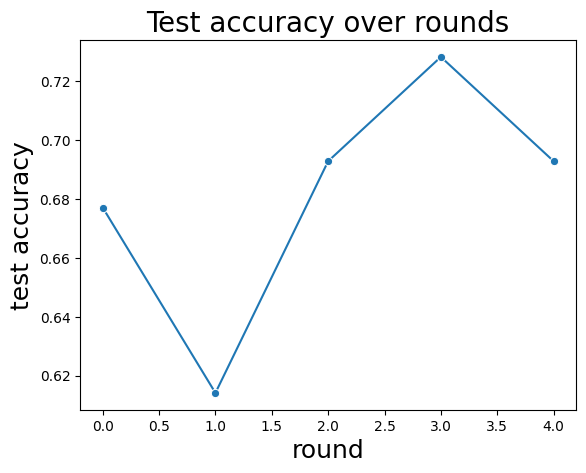

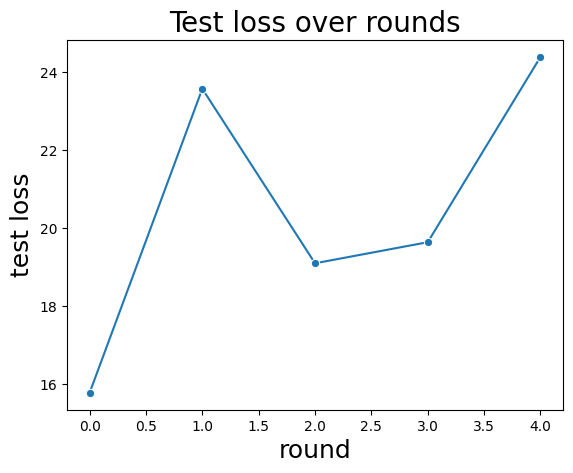

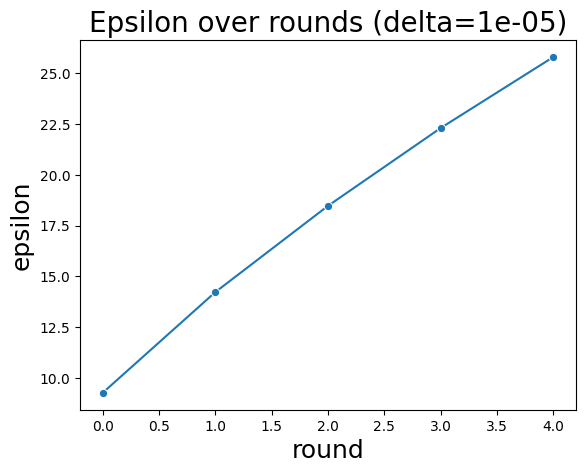

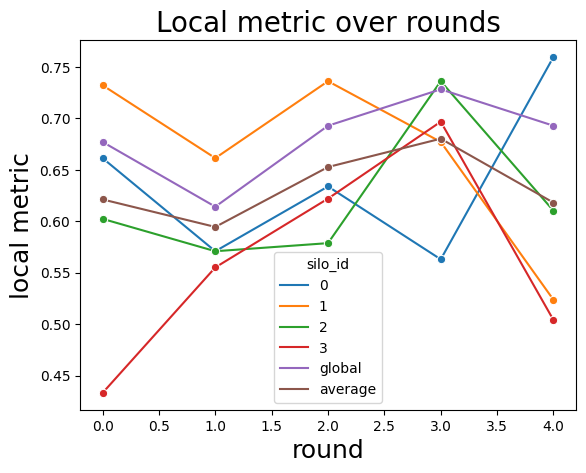

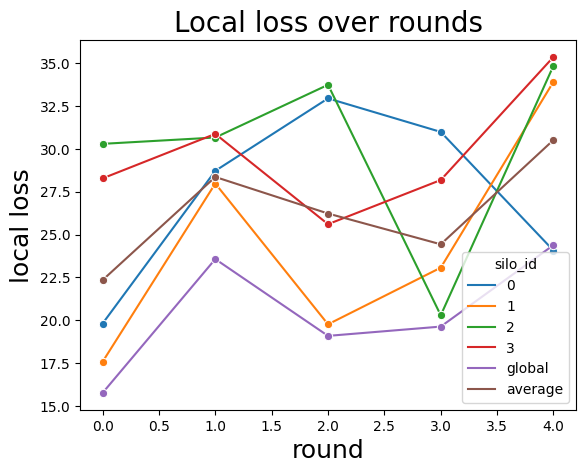

In [57]:
dataset_name = "heart_disease"
method = "ULDP-GROUP"
n_users = 10
group_k = 2
dist = None
plot_privacy_utility(dataset_name, method, n_users, group_k, dist)

## Medical dataset


- methods=("DEFAULT" "ULDP-NAIVE" "ULDP-GROUP" "ULDP-SGD" "ULDP-AVG")
- dataset_names=("heart_disease" "tcga_brca")
- n_users_list=(10 100 1100)
    - group_k=(4 8) for "ULDP-GROUP"


In [26]:
methods = ["DEFAULT", "ULDP-NAIVE", "ULDP-GROUP", "ULDP-SGD", "ULDP-AVG"]
group_k_list=[2, 4, 8]

dataset_names = ["heart_disease", "tcga_brca"]
n_users_list= [10, 100, 1100]

dataset_names_img = ["mnist"]
dist = [0, 1]
n_users_list_img = [100, 10000]

In [52]:
def plot_metric_per_method(dataset_name, n_users, methods, group_k_list):
    utility_metric_results = {"round_idx": [], "test_metric": [], "method": []}
    loss_metric_results = {"round_idx": [], "test_loss": [], "method": []}
    for method in methods:
        if method == "ULDP-GROUP":
            for group_k in group_k_list:
                exp_result_list, hash_args = exp_results(dataset_name, method, n_users, group_k)
                global_test_list = []
                for exp_result in exp_result_list:
                    global_test_list.extend(exp_result["global_test"])
                for round_idx, test_metric, test_loss in global_test_list:
                    utility_metric_results["round_idx"].append(round_idx)
                    utility_metric_results["test_metric"].append(test_metric)
                    utility_metric_results["method"].append(method + f"-{group_k}")
                    loss_metric_results["round_idx"].append(round_idx)
                    loss_metric_results["test_loss"].append(test_loss)
                    loss_metric_results["method"].append(method + f"-{group_k}")
        else:
            exp_result_list, hash_args = exp_results(dataset_name, method, n_users)
            global_test_list = []
            for exp_result in exp_result_list:
                global_test_list.extend(exp_result["global_test"])
            for round_idx, test_metric, test_loss in global_test_list:
                utility_metric_results["round_idx"].append(round_idx)
                utility_metric_results["test_metric"].append(test_metric)
                utility_metric_results["method"].append(method)
                loss_metric_results["round_idx"].append(round_idx)
                loss_metric_results["test_loss"].append(test_loss)
                loss_metric_results["method"].append(method)

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_metric",
        hue="method",
        hue_order=METHOD_ORDER,
        data=utility_metric_results,
        marker="o",
        ax=ax,
        alpha=0.8,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("Metric", fontsize=18)
    ax.set_title(f"Metric over rounds ({dataset_name}, {n_users})", fontsize=20)
    fig.savefig(
        os.path.join(img_path, f"{dataset_name}-{n_users}-global_test_acc_per_method.png"),
        dpi=100,
        bbox_inches="tight",
    )

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="test_loss",
        hue="method",
        hue_order=METHOD_ORDER,
        data=loss_metric_results,
        marker="o",
        ax=ax,
        alpha=0.8,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("test loss", fontsize=18)
    ax.set_title(f"Test loss over rounds ({dataset_name}, {n_users})", fontsize=20)
    fig.savefig(
        os.path.join(img_path, f"{dataset_name}-{n_users}-global_test_loss_per_method.png"),
        dpi=100,
        bbox_inches="tight",
    )


def plot_epsilon_per_method(dataset_name, n_users, methods, group_k_list):
    privacy_results = {"round_idx": [], "epsilon": [], "method": []}
    delta = 0
    for method in methods:
        if method == "ULDP-GROUP":
            for group_k in group_k_list:
                exp_result_list, hash_args = exp_results(dataset_name, method, n_users, group_k)
                privacy_budget_list = exp_result_list[0]['privacy_budget']
                if len(privacy_budget_list) == 0:
                    continue
                delta = privacy_budget_list[0][2]
                for round_idx, eps, _ in privacy_budget_list:
                    privacy_results["round_idx"].append(round_idx)
                    privacy_results["epsilon"].append(eps)
                    privacy_results["method"].append(method + f"-{group_k}")

        else:
            exp_result_list, hash_args = exp_results(dataset_name, method, n_users)
            privacy_budget_list = exp_result_list[0]['privacy_budget']
            if len(privacy_budget_list) == 0:
                continue
            delta = privacy_budget_list[0][2]
            for round_idx, eps, _ in privacy_budget_list:
                privacy_results["round_idx"].append(round_idx)
                privacy_results["epsilon"].append(eps)
                privacy_results["method"].append(method)

    fig, ax = plt.subplots(1, 1)
    sns.lineplot(
        x="round_idx",
        y="epsilon",
        hue="method",
        hue_order=METHOD_ORDER,
        data=privacy_results,
        style="method",
        markers=PLOT_MARKERS,
        markersize=10,
        alpha=0.4,
        ax=ax,
    )
    ax.set_xlabel("round", fontsize=18)
    ax.set_ylabel("epsilon", fontsize=18)
    ax.set_title(f"Epsilon over rounds (delta={delta}) ({dataset_name}, {n_users})", fontsize=20)
    fig.savefig(
        os.path.join(img_path, f"{dataset_name}-{n_users}-global_epsilon.png"),
        dpi=100,
        bbox_inches="tight",
    )


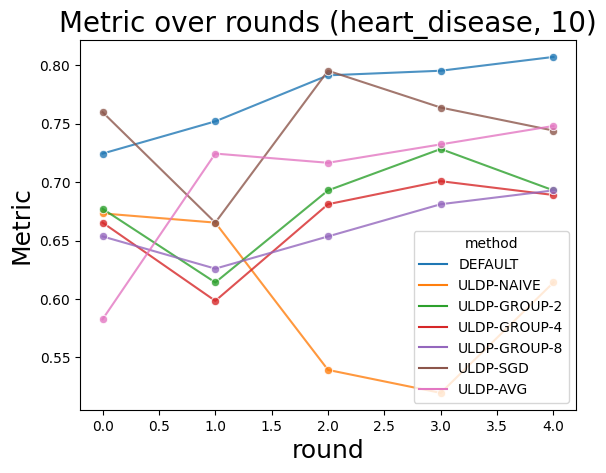

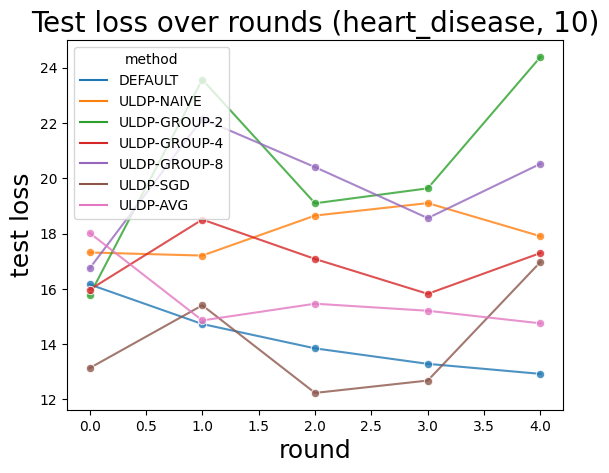

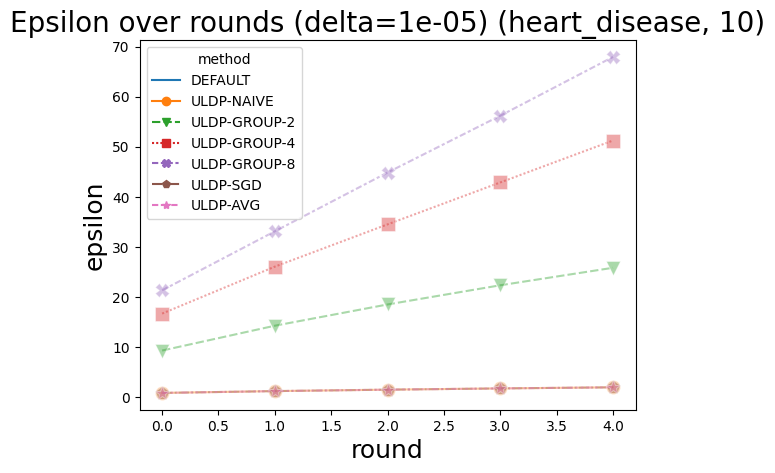

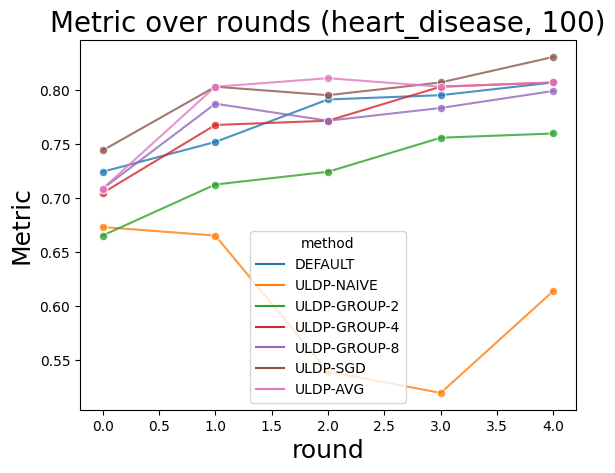

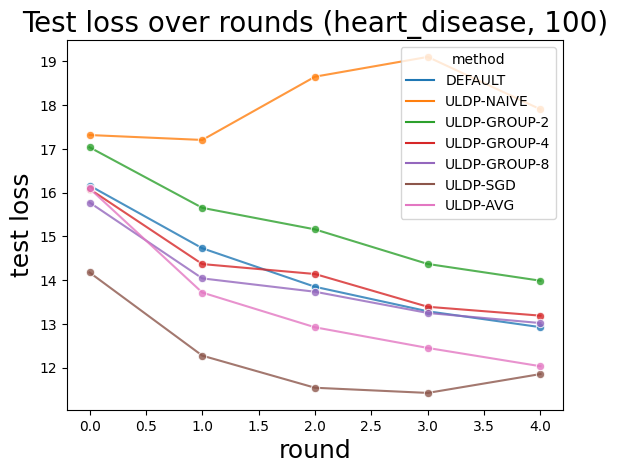

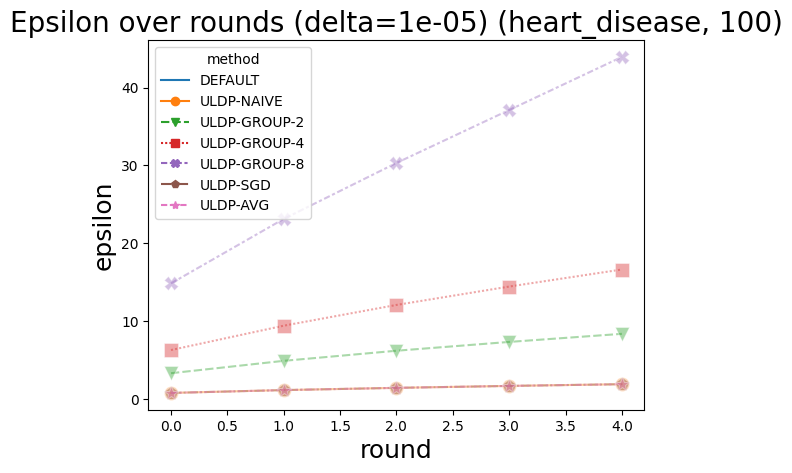

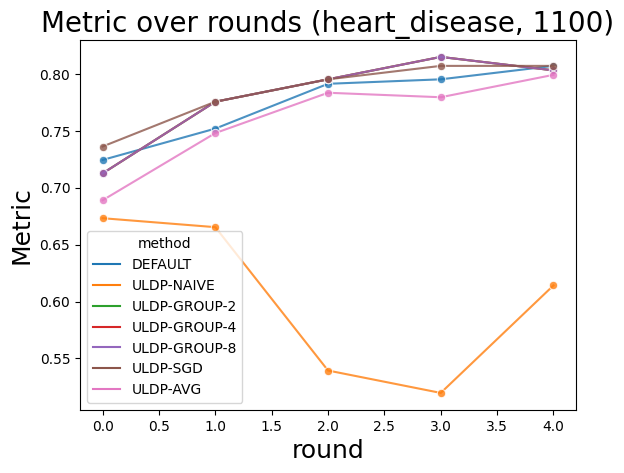

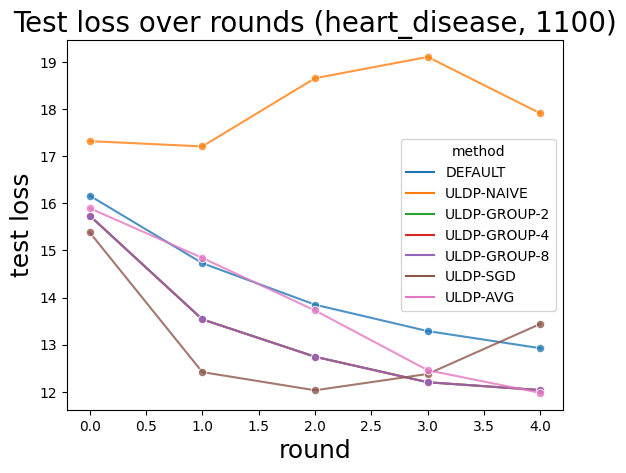

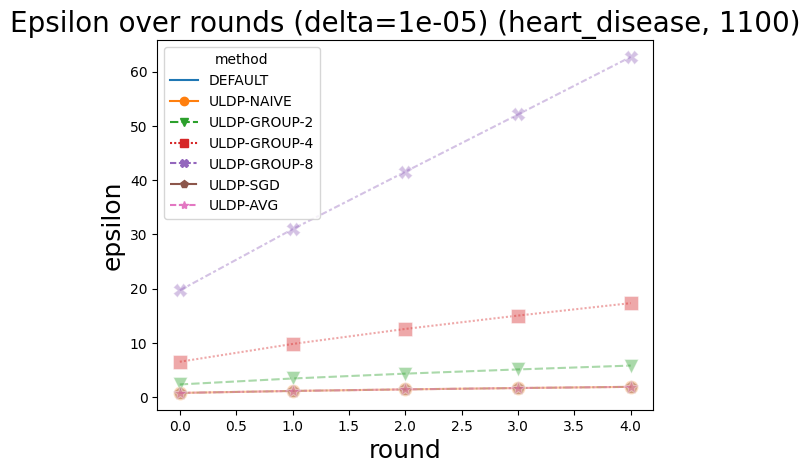

In [53]:
methods = ["DEFAULT", "ULDP-NAIVE", "ULDP-GROUP", "ULDP-SGD", "ULDP-AVG"]
dataset_names = ["heart_disease"]
n_users_list= [10, 100, 1100]
group_k_list=[2, 4, 8]
for dataset_name in dataset_names:
    for n_users in n_users_list:
        plot_metric_per_method(dataset_name, n_users, methods, group_k_list)
        plot_epsilon_per_method(dataset_name, n_users, methods, group_k_list)